In [23]:
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [24]:
from dotenv import load_dotenv
load_dotenv()

True

In [25]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [26]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")


In [27]:
def chatboot(state):
    return {"messages" : llm.invoke(state["messages"])}

In [28]:
graph_builder.add_node("llmChatBot", chatboot)

graph_builder.add_edge(START, "llmChatBot")
graph_builder.add_edge("llmChatBot", END)

graph = graph_builder.compile()

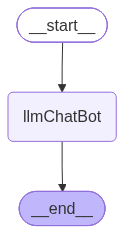

In [29]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))



In [32]:
response = graph.invoke({"messages": "What I asked justnow?"})

In [35]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What I asked justnow?
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "What I asked justnow?"
   - This is a follow-up question, but there's no prior conversation history provided in this prompt.
   - The user is asking what they just asked, implying they think there was a previous message.

2.  **Identify Key Constraint:**
   - As an AI, I only have access to the current conversation thread. In this case, the conversation only contains this single message.
   - I don't have memory of past interactions outside this session.

3.  **Formulate Response:**
   - Acknowledge the question politely.
   - Explain that I don't have access to previous messages or conversation history beyond this current session.
   - Clarify that this appears to be the first message in our current conversation.
   - Off